In [1]:
import json
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_1.npz"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

CVT_PATH = "data/Archive/CVT/cvt run tita 1/cvt/"

cvt_elites_path = CVT_PATH + "elites.json"

with open(cvt_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))
print("number of embeddings:", len(_embeddings))


Number of elites: 300
number of embeddings: 19672


In [2]:
# 402.2980307006009, 584.9278792454614, 120.05557356154652, 300.36740629503026
ids = [46.14107942908127, 658.6419409276459, 654.7070314086919, 856.4539960144075, 346.5989534591662, 698.1124466369452]
elite_dict = {elite["id"]: elite["embedding"] for elite in elites}
selected_embeddings = [elite_dict[i] for i in ids]

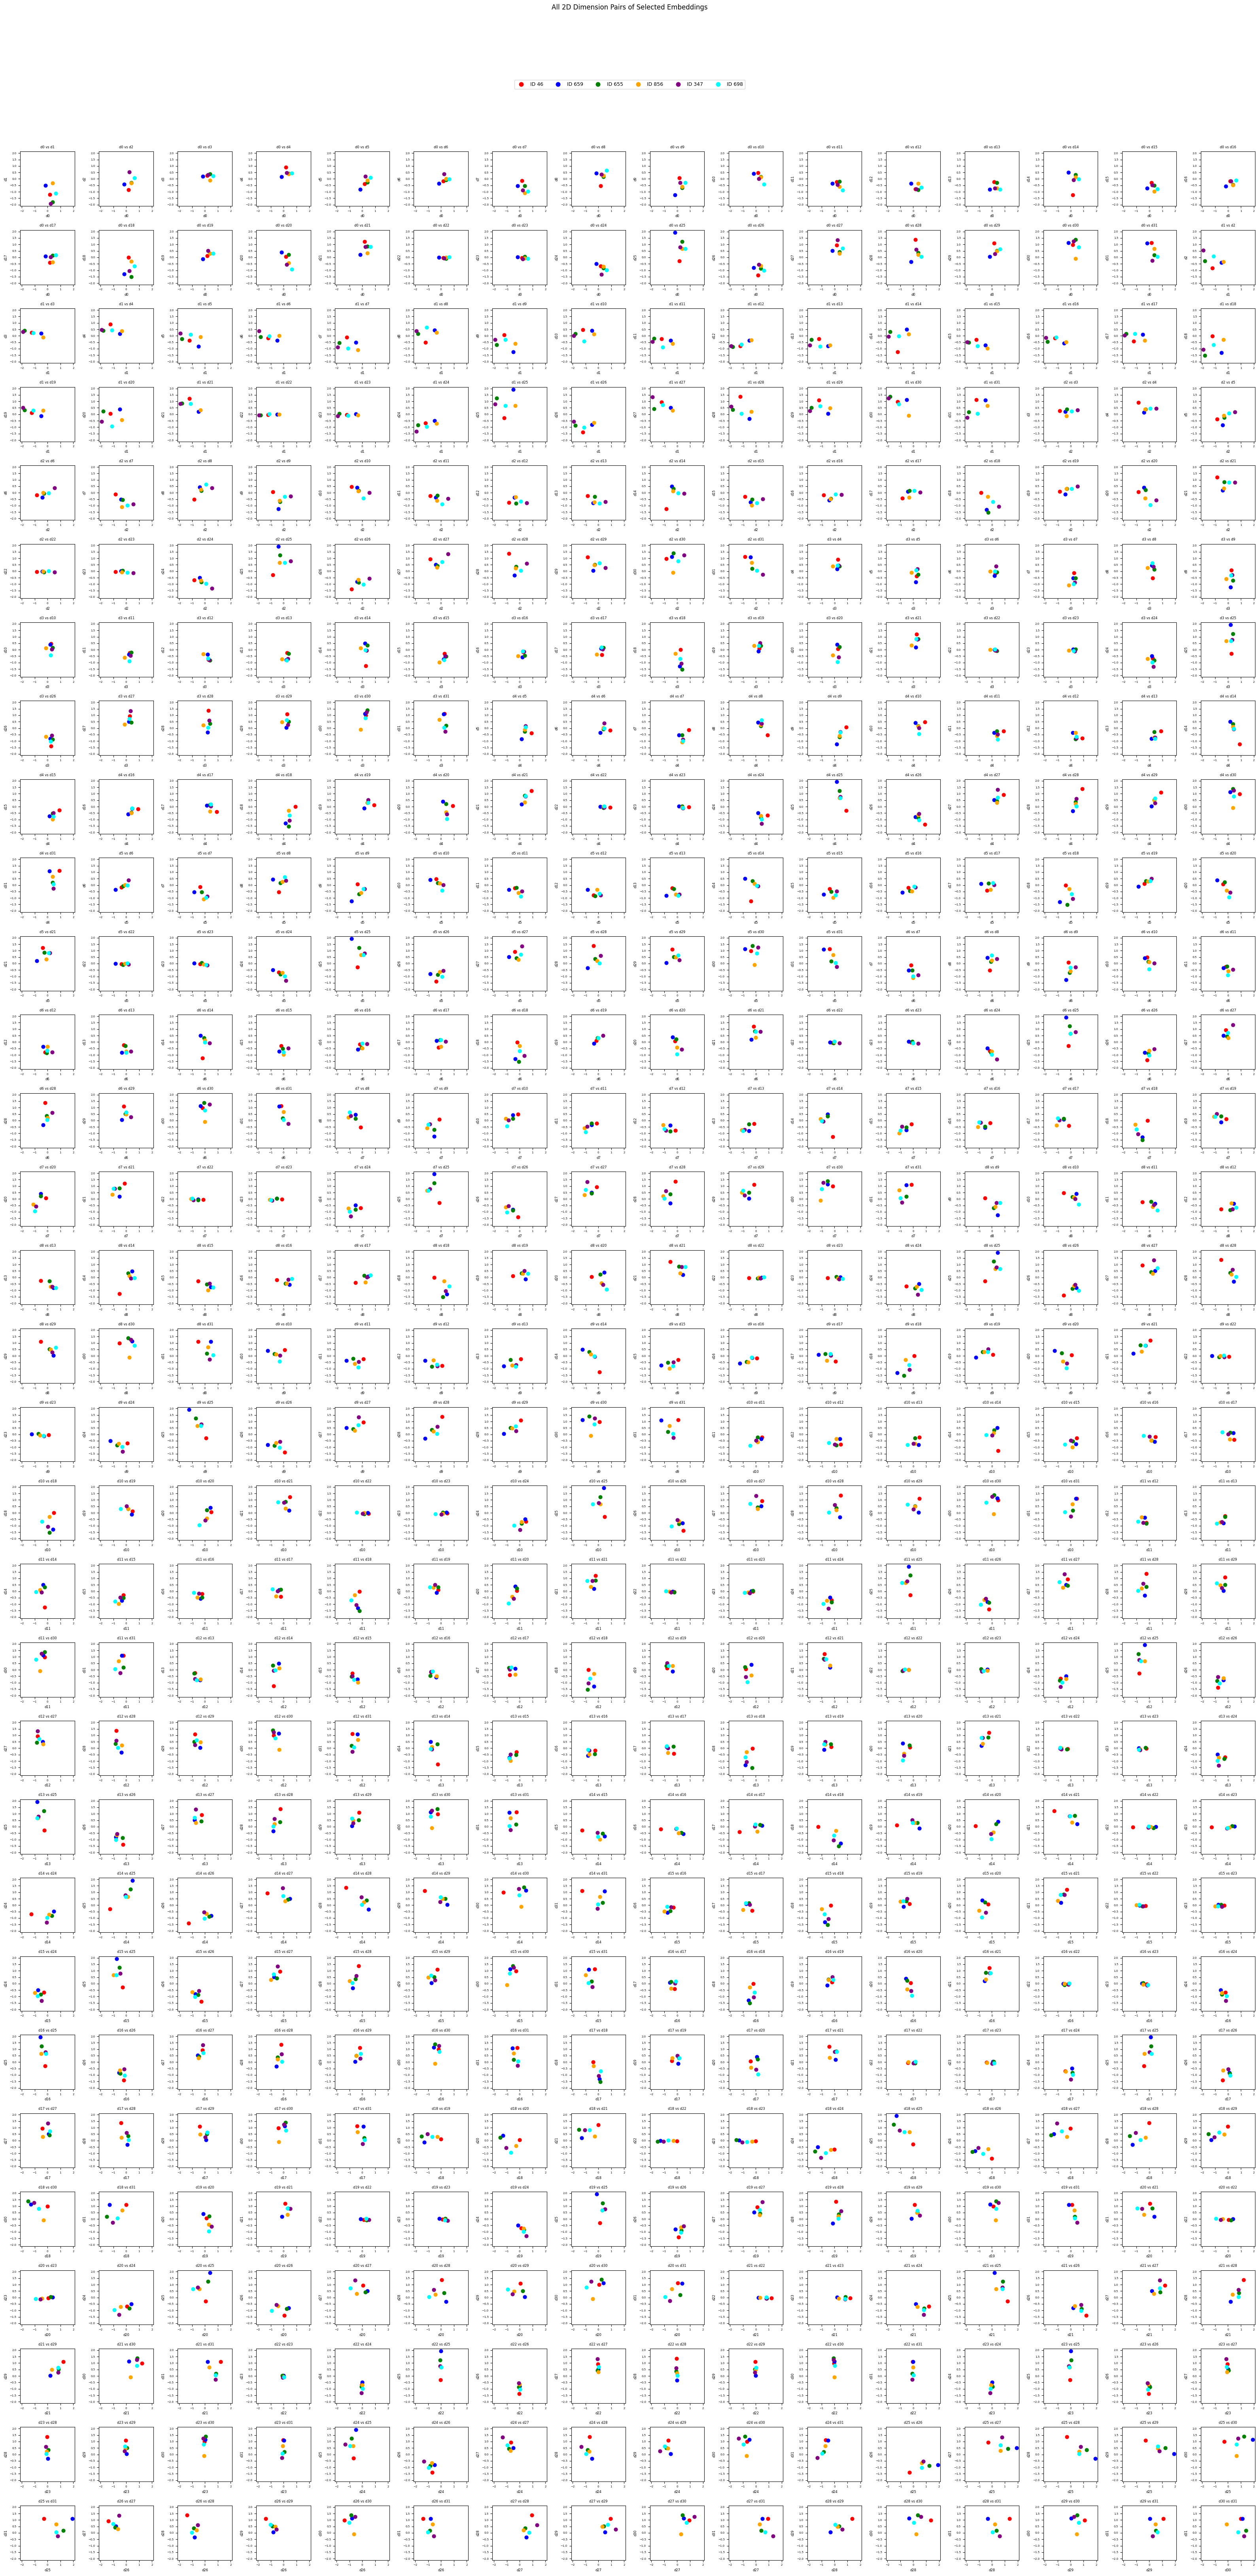

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

selected_embeddings_arr = np.array(selected_embeddings)
n_dims = selected_embeddings_arr.shape[1]
labels = [f"ID {id:.0f}" for id in ids]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink', 'gray', 'olive'][:len(ids)]

dim_pairs = list(combinations(range(n_dims), 2))
n_plots = len(dim_pairs)
n_cols = 16
n_rows = (n_plots + n_cols - 1) // n_cols

# Compute global axis limits across all dimensions
global_min = selected_embeddings_arr.min()
global_max = selected_embeddings_arr.max()
margin = (global_max - global_min) * 0.05

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(dim_pairs):
    ax = axes[idx]
    for i, emb in enumerate(selected_embeddings_arr):
        ax.scatter(emb[d1], emb[d2], color=colors[i], s=40)
    ax.set_xlim(global_min - margin, global_max + margin)
    ax.set_ylim(global_min - margin, global_max + margin)
    ax.set_aspect('equal')
    ax.set_xlabel(f"d{d1}", fontsize=6)
    ax.set_ylabel(f"d{d2}", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_title(f"d{d1} vs d{d2}", fontsize=6)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

# Legend at the top
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
           for c, l in zip(colors, labels)]
fig.legend(handles=handles, labels=labels, loc='upper center', ncol=len(labels),
           fontsize=9, markerscale=1.2, bbox_to_anchor=(0.5, 1.02), frameon=True)

plt.suptitle("All 2D Dimension Pairs of Selected Embeddings", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

In [5]:
import umap
import os
import matplotlib.pyplot as plt
import numpy as np
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = _embeddings
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")


Loaded precomputed embeddings with shape: (19672, 32)


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings x,y borders:
x: min=-0.16545291244983673, max=8.359619140625
y: min=-3.1245930194854736, max=3.884744167327881


Elite ID 46.14107942908127 UMAP 2D coords: [1.4067332 1.177137 ]
Elite ID 658.6419409276459 UMAP 2D coords: [ 5.4554243 -1.8620297]
Elite ID 654.7070314086919 UMAP 2D coords: [ 5.446015  -1.6751287]
Elite ID 856.4539960144075 UMAP 2D coords: [ 5.428949  -1.3014625]
Elite ID 346.5989534591662 UMAP 2D coords: [ 4.562908 -1.255113]
Elite ID 698.1124466369452 UMAP 2D coords: [ 4.952308   -0.93956846]


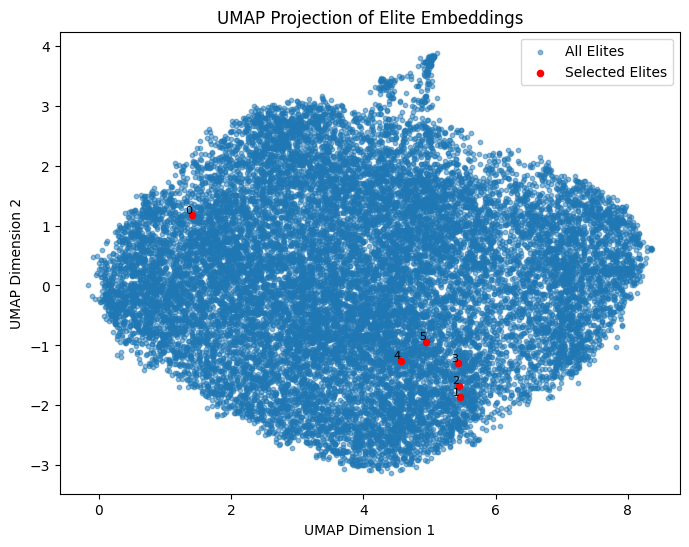

In [6]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
elite_ids = ids

# Preserve order of elite_ids
id_to_elite = {elite["id"]: elite for elite in elites}
selected_elites = [id_to_elite[eid] for eid in elite_ids if eid in id_to_elite]
selected_embeddings = [elite["embedding"] for elite in selected_elites]

reduced_points = []
for elite in selected_elites:
    embedding = elite["embedding"]
    point = umap_model.transform([embedding])[0]
    print(f"Elite ID {elite['id']} UMAP 2D coords: {point}")
    reduced_points.append(point)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            s=10, alpha=0.5, label="All Elites")

reduced_points = np.array(reduced_points)
plt.scatter(reduced_points[:, 0], reduced_points[:, 1],
            s=20, color="red", label="Selected Elites")

# Add numbering based on order in elite_ids
for i, (x, y) in enumerate(reduced_points):
    plt.text(x, y, str(i), fontsize=8, ha='right', va='bottom', color='black')

plt.title("UMAP Projection of Elite Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

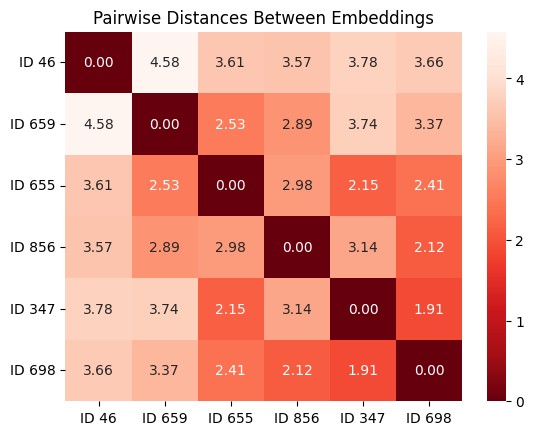

In [7]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {id:.0f}" for id in ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".2f")
plt.title("Pairwise Distances Between Embeddings")
plt.yticks(rotation=0)
plt.show()

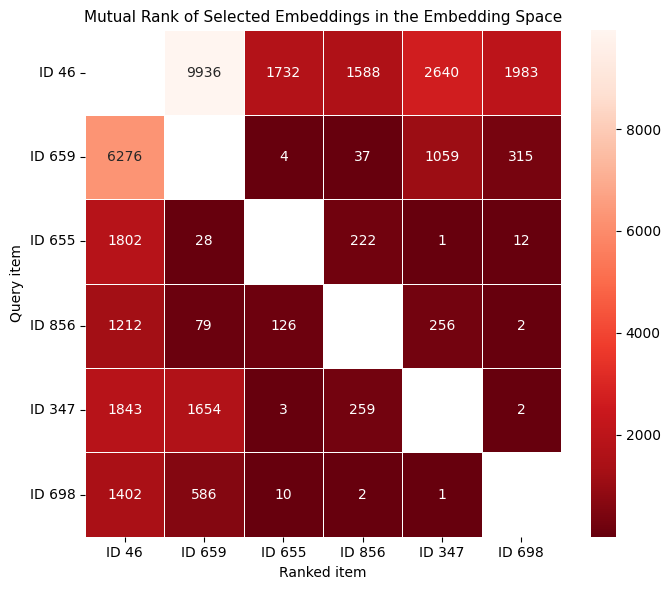

In [8]:
from sklearn.metrics.pairwise import euclidean_distances

all_embeddings = np.array(_embeddings)
selected_embeddings_vecs = np.array(selected_embeddings)
all_embeddings = np.vstack((all_embeddings, selected_embeddings_vecs))

# compute distances from each selected embedding to all embeddings
distances = euclidean_distances(selected_embeddings_vecs, all_embeddings)

# Rank all embeddings for each selected embedding (ascending: closest first)
rankings = np.argsort(distances, axis=1)

# print where each selected_embedding is in the ranking of the others
n_all = len(all_embeddings)
n_selected = len(selected_embeddings_vecs)
selected_indices = list(range(n_all - n_selected, n_all))

# Build rank matrix: rank_matrix[i][j] = rank of ids[j] in ids[i]'s ranking
rank_matrix = np.full((n_selected, n_selected), np.nan)

for i, sel_idx in enumerate(selected_indices):
    for j, other_idx in enumerate(selected_indices):
        if i == j:
            continue
        position = np.where(rankings[i] == other_idx)[0][0]
        rank_matrix[i][j] = position

# Short labels for readability
labels = [f"ID {id:.0f}" for id in ids]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    rank_matrix,
    annot=True,
    fmt=".0f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",      # lower rank (closer) = darker
    linewidths=0.5,
    ax=ax,
    mask=np.eye(n_selected, dtype=bool)  # mask diagonal (self)
)
ax.set_title("Mutual Rank of Selected Embeddings in the Embedding Space", fontsize=11)
ax.set_xlabel("Ranked item")
ax.set_ylabel("Query item")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2026-03-31 14:27:30 [info     ] Checkpoint loaded              path='data/Archive/CVT/cvt run tita 1/cvt/checkpoints\\checkpoint_0999.pkl' resume_iter=1000


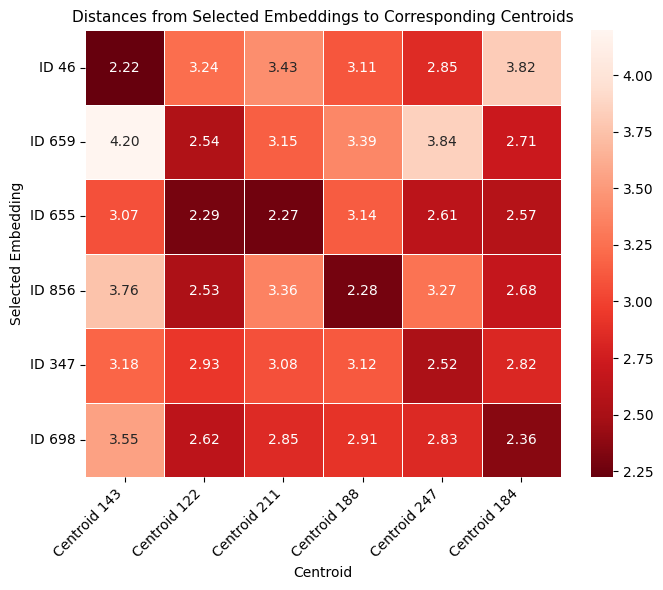

In [9]:
import sys
from mapelite.qd_runner import QDRunner
import mapelite.emitter as emitter_module
import mapelite.utils as utils_module
import mapelite.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'mapelite.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = CVT_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
archive = state["archive"]

centroids = getattr(archive, "centroids", None)

selected_centroid_idxs = archive.index_of(selected_embeddings_vecs)
selected_centroids = np.array(centroids[selected_centroid_idxs])

distances = euclidean_distances(selected_embeddings_vecs, selected_centroids)

# Short labels for readability
labels_y = [f"ID {id:.0f}" for id in ids]
labels_x = [f"Centroid {idx}" for idx in selected_centroid_idxs]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    distances,
    annot=True,
    fmt=".2f",
    xticklabels=labels_x,
    yticklabels=labels_y,
    cmap="Reds_r",      # lower rank (closer) = darker
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Distances from Selected Embeddings to Corresponding Centroids", fontsize=11)
ax.set_xlabel("Centroid")
ax.set_ylabel("Selected Embedding")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()